# Análise de Dados - Survey Câncer de Pulmão

Análise exploratória do dataset de câncer de pulmão usando Python e Machine Learning

## Importação das Bibliotecas

Esta célula importa todas as bibliotecas necessárias para a análise:
- **pandas**: Manipulação e análise de dados tabulares
- **sklearn**: Algoritmos de machine learning (classificação, métricas, pré-processamento)
- **matplotlib.pyplot**: Criação de gráficos básicos
- **seaborn**: Visualizações estatísticas avançadas
- **numpy**: Operações numéricas e arrays

In [1]:
# Importar bibliotecas necessárias
import pandas as pd # Para trabalhar com dados tabulares
from sklearn.model_selection import train_test_split # Separação dos dados
from sklearn.neighbors import KNeighborsClassifier # Modelo de machine learning classificação
from sklearn.metrics import accuracy_score # Avaliação do modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Avaliação do modelo
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Feature Engineering
import matplotlib.pyplot as plt # Gráficos
import seaborn as sns # Gráficos
import numpy as np # Transformação dos dados
import seaborn as sb # Gráficos
from sklearn.preprocessing import LabelEncoder # Transformação dos dados

## Descrição do Dataset

Este dataset contém informações sobre fatores de risco associados ao câncer de pulmão. As colunas representam:

- **Gênero**: M (masculino), F (feminino)
- **Idade**: Idade do paciente
- **Fumar**: SIM=2, NÃO=1
- **Dedos amarelos**: SIM=2, NÃO=1
- **Ansiedade**: SIM=2, NÃO=1
- **Pressão dos pares**: SIM=2, NÃO=1
- **Doença crônica**: SIM=2, NÃO=1
- **Fadiga**: SIM=2, NÃO=1
- **Alergia**: SIM=2, NÃO=1
- **Chiado no peito**: SIM=2, NÃO=1
- **Álcool**: SIM=2, NÃO=1
- **Tosse**: SIM=2, NÃO=1
- **Falta de ar**: SIM=2, NÃO=1
- **Dificuldade para engolir**: SIM=2, NÃO=1
- **Dor no peito**: SIM=2, NÃO=1
- **Câncer de pulmão**: SIM, NÃO

## 1. Carregamento dos Dados

Carregando o dataset survey lung cancer em um DataFrame do Pandas

In [2]:
# Carregar os dados
dados = pd.read_csv('dataset.csv', sep=',')

# Visualizar os primeiros registros
dados.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


## Carregamento e Primeira Visualização dos Dados

Esta seção carrega o dataset CSV e mostra os primeiros registros para entender a estrutura dos dados.

## 2. Exploração Inicial dos Dados

Analisando as dimensões e verificando valores faltantes

In [3]:
# Dimensões do dataset (linhas, colunas)
print("Dimensões do dataset:")
dados.shape

Dimensões do dataset:


(3000, 16)

## Exploração Inicial dos Dados

Esta seção realiza uma análise preliminar do dataset:
- Verifica as dimensões (número de linhas e colunas)
- Identifica valores nulos/missing
- Mostra informações sobre tipos de dados
- Estatísticas descritivas básicas

In [4]:
print("\nValores nulos por coluna:")
dados.isnull().sum()


Valores nulos por coluna:


GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              0
dtype: int64

In [5]:
print("\nInformações do dataset:")
dados.info()


Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 3000 non-null   str  
 1   AGE                    3000 non-null   int64
 2   SMOKING                3000 non-null   int64
 3   YELLOW_FINGERS         3000 non-null   int64
 4   ANXIETY                3000 non-null   int64
 5   PEER_PRESSURE          3000 non-null   int64
 6   CHRONIC_DISEASE        3000 non-null   int64
 7   FATIGUE                3000 non-null   int64
 8   ALLERGY                3000 non-null   int64
 9   WHEEZING               3000 non-null   int64
 10  ALCOHOL_CONSUMING      3000 non-null   int64
 11  COUGHING               3000 non-null   int64
 12  SHORTNESS_OF_BREATH    3000 non-null   int64
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64
 14  CHEST_PAIN             3000 non-null   int64
 15  LUNG_CANCER            3

In [6]:
print("\nDescrição estatística dos dados numéricos:")
dados.describe()


Descrição estatística dos dados numéricos:


,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667
std,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,80.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [7]:
print("\nNúmero de registros duplicados:")
dados.duplicated().sum()


Número de registros duplicados:


2

## Limpeza de Dados

Esta seção trata da limpeza e preparação dos dados:
- Identifica e remove registros duplicados
- Garante qualidade dos dados para análise

In [8]:
dados.drop_duplicates(inplace=True)

In [10]:

print("\nContagem de valores únicos na coluna 'GENDER':")
print("Para indentificar o nuúmero de registros masculinos e femininos:")
dados['GENDER'].value_counts()


Contagem de valores únicos na coluna 'GENDER':
Para indentificar o nuúmero de registros masculinos e femininos:


GENDER
M    1512
F    1486
Name: count, dtype: int64

In [11]:

print("\nContagem de valores únicos na coluna 'LUNG_CANCER':")
print("Para identificar o número de registros com e sem câncer de pulmão:")
dados['LUNG_CANCER'].value_counts()


Contagem de valores únicos na coluna 'LUNG_CANCER':
Para identificar o número de registros com e sem câncer de pulmão:


LUNG_CANCER
YES    1517
NO     1481
Name: count, dtype: int64

In [12]:
print("Contagem dos valores únicos por idade:")
dados['AGE'].value_counts()

Contagem dos valores únicos por idade:


AGE
54    73
67    71
75    71
47    70
69    70
55    69
78    69
79    68
32    66
39    65
37    65
53    65
77    64
46    64
63    63
33    62
50    62
70    61
68    61
35    60
48    60
36    60
76    59
71    59
31    59
62    58
57    58
56    58
60    57
80    57
34    57
52    57
61    57
64    56
41    56
42    56
49    56
51    55
59    55
43    55
44    54
38    53
58    51
40    51
74    50
65    49
66    48
45    47
72    46
73    43
30    42
Name: count, dtype: int64

In [13]:
Total = len(dados)
temCancer = dados[dados["LUNG_CANCER"] == 'YES'].LUNG_CANCER.count()
naoTemCancer = dados[dados["LUNG_CANCER"] == 'NO'].LUNG_CANCER.count()

Percentual_tem_cancer = temCancer / Total 

print("Total de dados: ", Total)
print("Total de pessoas que não tem cancer: ", naoTemCancer)
print("Total de pessoas que tem cancer: ", temCancer)
print("Percentual que tem cancer: ", (round(Percentual_tem_cancer, 2)*100), "%")

Total de dados:  2998
Total de pessoas que não tem cancer:  1481
Total de pessoas que tem cancer:  1517
Percentual que tem cancer:  51.0 %


## Análise da Variável Alvo (Câncer de Pulmão)

Esta seção analisa a distribuição da variável dependente:
- Contagem de casos positivos e negativos
- Cálculo de percentuais
- Visualização com gráfico de pizza


Distribuição de câncer de pulmão:


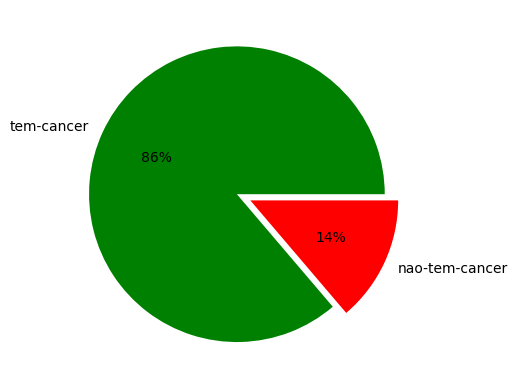

In [15]:

print("\nDistribuição de câncer de pulmão:")
categororias = ["tem-cancer", "nao-tem-cancer"]
plt.pie(dados["LUNG_CANCER"].value_counts(), labels = categororias, autopct = "%.0f%%", explode= (0, 0.1), colors = ("g", "r"))
plt.show()

In [16]:
totalTemCancer = dados[dados["LUNG_CANCER"] == 'YES']

## Análise dos Pacientes com Câncer

Esta seção foca nos pacientes diagnosticados com câncer:
- Filtra apenas casos positivos
- Mostra estatísticas descritivas dos fatores de risco
- Cria visualizações dos padrões encontrados

In [17]:
totalTemCancer.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES


In [18]:

print("\nDescrição estatística dos registros com câncer de pulmão:")
totalTemCancer.describe().T


Descrição estatística dos registros com câncer de pulmão:


,count,mean,std,min,25%,50%,75%,max
AGE,238.0,63.264706,8.105924,38.0,58.0,63.0,70.0,81.0
SMOKING,238.0,1.550420,0.498500,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,238.0,1.613445,0.487986,1.0,1.0,2.0,2.0,2.0
ANXIETY,238.0,1.525210,0.500416,1.0,1.0,2.0,2.0,2.0
PEER_PRESSURE,238.0,1.546218,0.498908,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,238.0,1.550420,0.498500,1.0,1.0,2.0,2.0,2.0
FATIGUE,238.0,1.693277,0.462105,1.0,1.0,2.0,2.0,2.0
ALLERGY,238.0,1.613445,0.487986,1.0,1.0,2.0,2.0,2.0
WHEEZING,238.0,1.596639,0.491606,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,238.0,1.609244,0.488948,1.0,1.0,2.0,2.0,2.0


<Axes: xlabel='COUGHING', ylabel='count'>

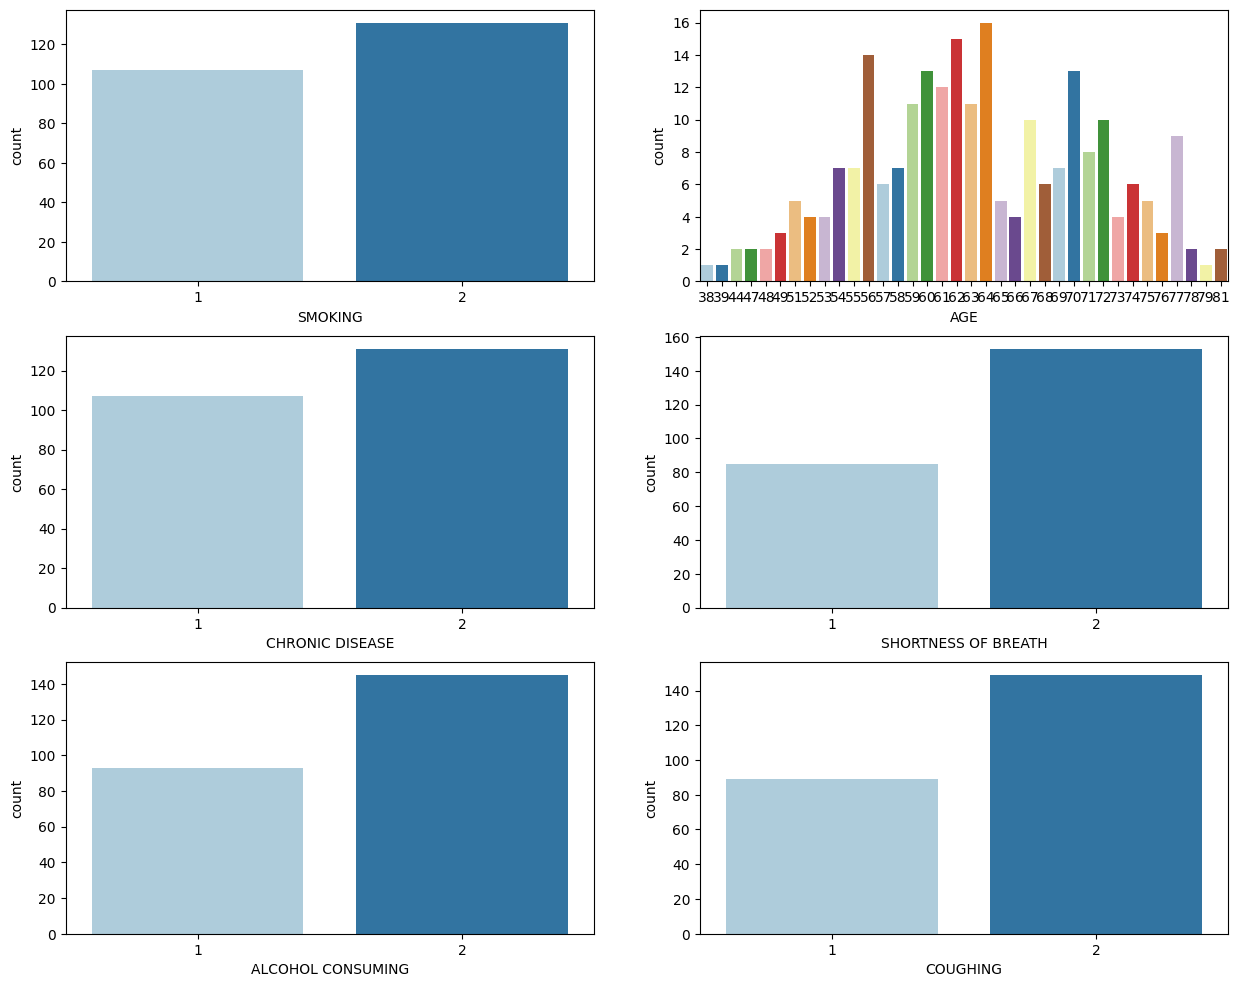

In [19]:
plt.figure(figsize = (15,12))

plt.subplot(3,2,1)
sns.countplot(x = "SMOKING", hue="SMOKING", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,2)
sns.countplot(x = "AGE", hue="AGE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,3)
sns.countplot(x = "CHRONIC DISEASE", hue="CHRONIC DISEASE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,4)
sns.countplot(x = "SHORTNESS OF BREATH", hue="SHORTNESS OF BREATH", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,5)
sns.countplot(x = "ALCOHOL CONSUMING", hue="ALCOHOL CONSUMING", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,6)
sns.countplot(x = "COUGHING", hue="COUGHING", palette = "Paired", data = totalTemCancer, legend=False)


/var/folders/t4/3td2bmbs6h38d0yjvn8hwfjn_473md/T/ipykernel_60656/1999815708.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')


<Axes: xlabel='LUNG_CANCER', ylabel='SMOKING'>

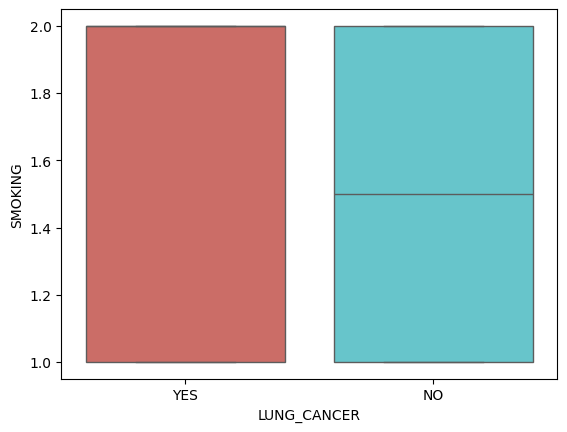

In [20]:


sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')

<Axes: xlabel='AGE'>

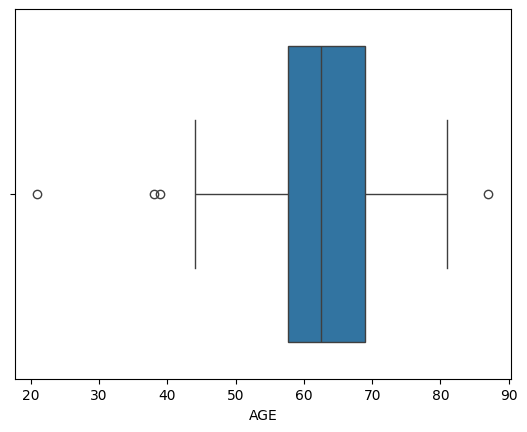

In [21]:
sb.boxplot(x=dados["AGE"])

## Visualizações dos Fatores de Risco

Esta seção cria gráficos para entender os fatores de risco:
- Gráficos de barras mostrando distribuição dos fatores
- Histogramas para variáveis numéricas
- Análise visual dos padrões nos pacientes com câncer

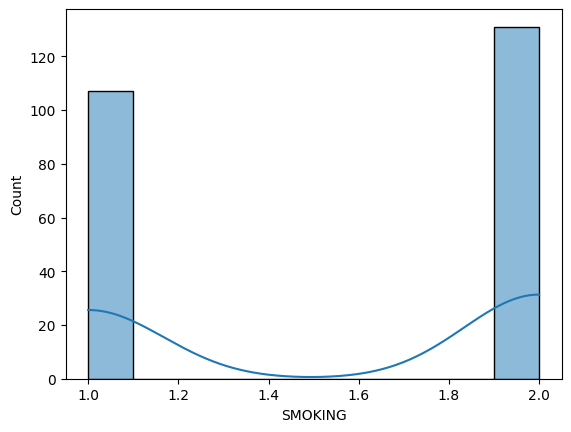

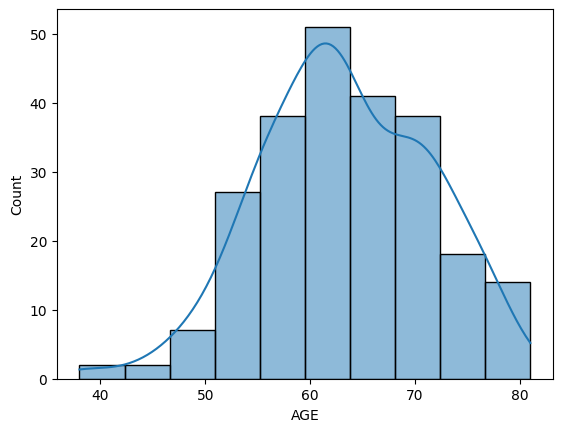

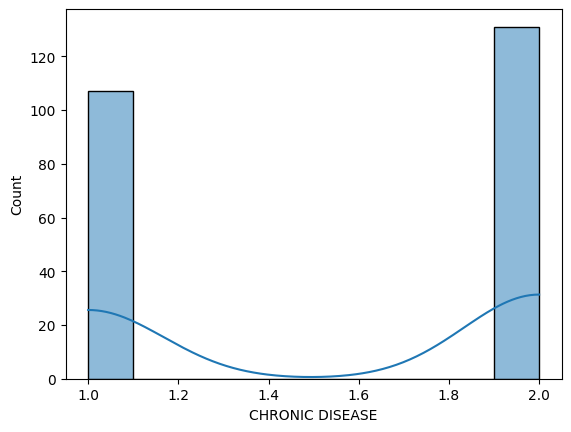

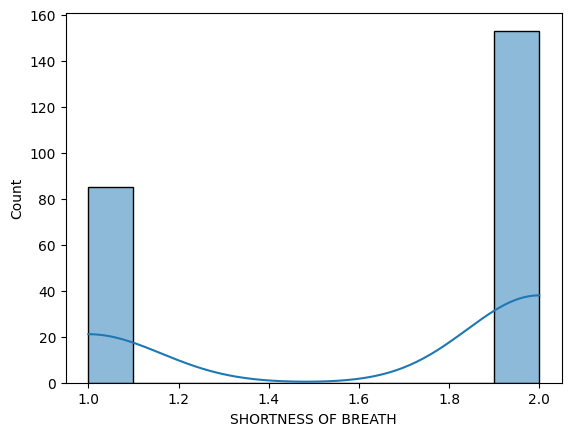

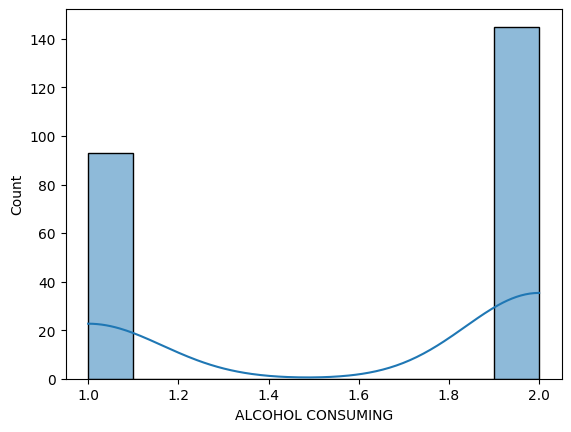

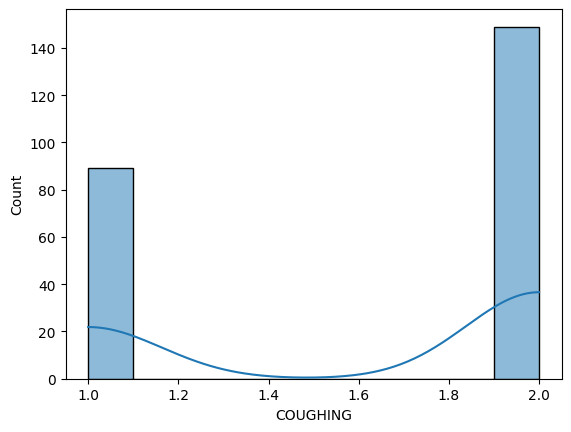

In [22]:
Colunas_Numericas = ["SMOKING", "AGE", "CHRONIC DISEASE", "SHORTNESS OF BREATH", "ALCOHOL CONSUMING", "COUGHING"]
for column in Colunas_Numericas:
    plt.figure()
    plot = totalTemCancer[column]
    sns.histplot(plot, bins=10, kde=True)
    plt.show()

In [26]:
le = LabelEncoder()

dados['GENDER'] = le.fit_transform(dados['GENDER'])

dados['LUNG_CANCER'] = le.fit_transform(dados['LUNG_CANCER'])

## Análise de Correlação

Esta seção analisa as relações entre os fatores de risco:
- Calcula correlação de Pearson entre variáveis numéricas
- Cria heatmap para visualizar associações
- Ordena as variáveis pela força de correlação com `LUNG_CANCER`
- Destaca visualmente quais fatores têm maior associação com o diagnóstico

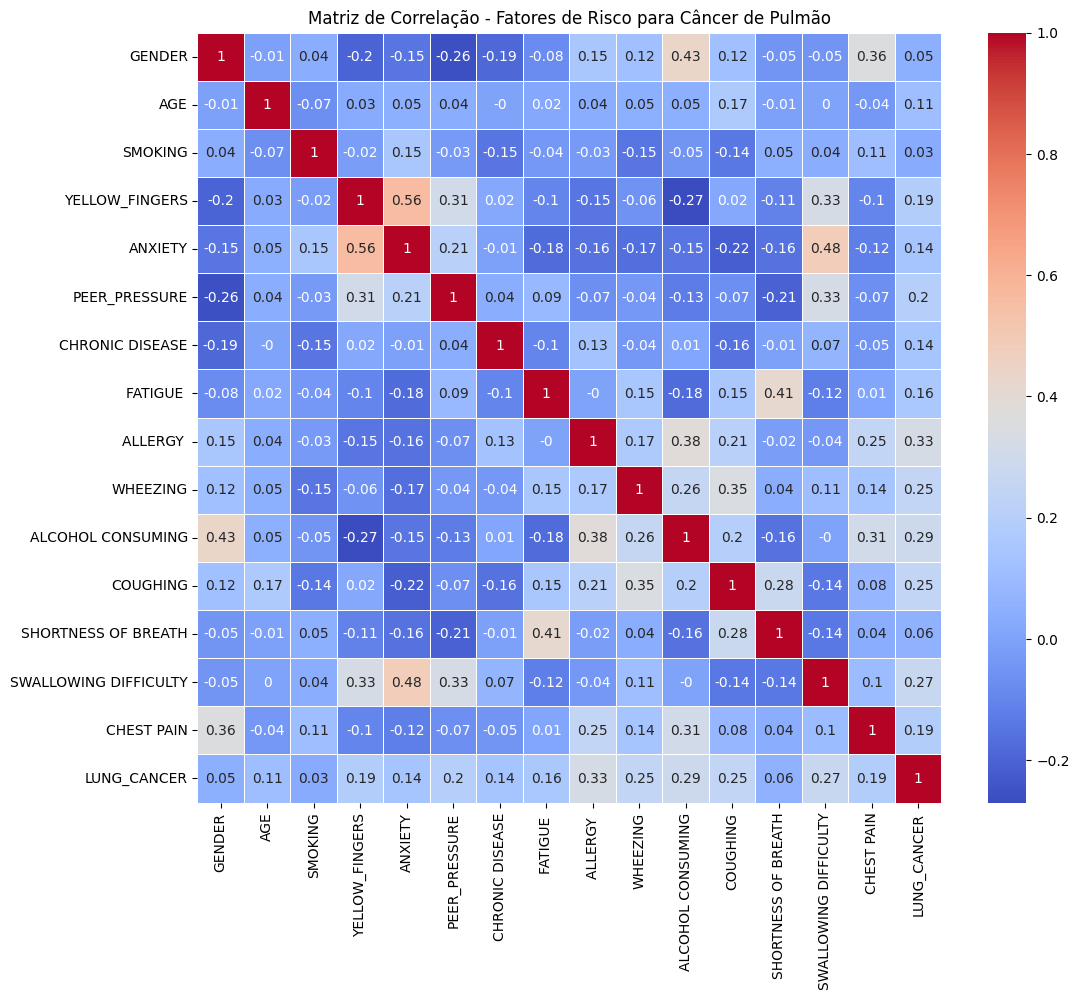

In [27]:
# Calcular correlação apenas para colunas numéricas
correlation_matrix = dados.select_dtypes(include=[np.number]).corr().round(2)

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax, cmap='coolwarm')
plt.title('Matriz de Correlação - Fatores de Risco para Câncer de Pulmão')
plt.show()

Correlação das variáveis com LUNG_CANCER:


,correlacao
ALLERGY,0.33
ALCOHOL CONSUMING,0.29
SWALLOWING DIFFICULTY,0.27
WHEEZING,0.25
COUGHING,0.25
PEER_PRESSURE,0.20
YELLOW_FINGERS,0.19
CHEST PAIN,0.19
FATIGUE,0.16
ANXIETY,0.14


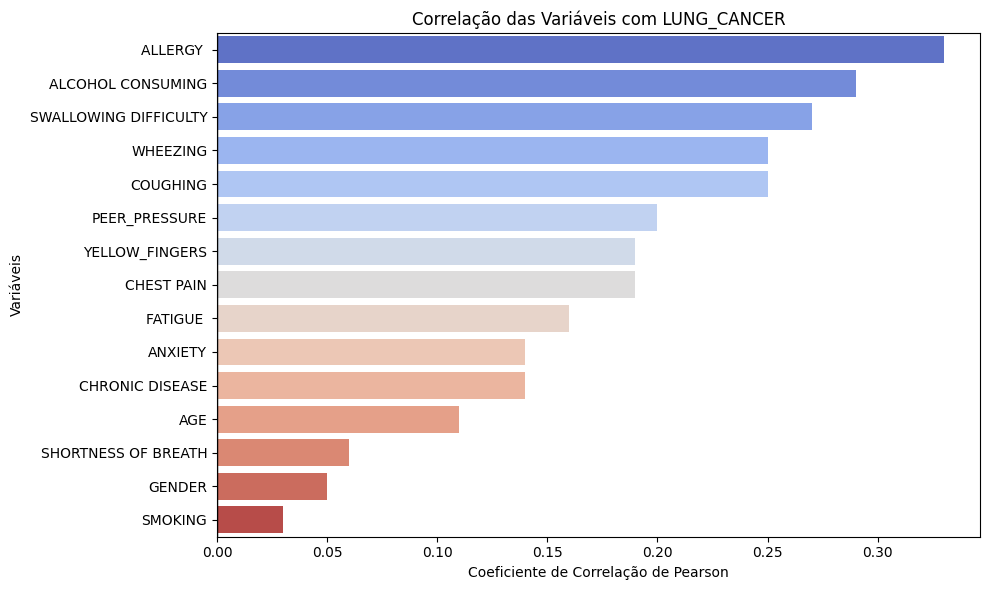

In [28]:
# Destacar a correlação das variáveis com a variável alvo
correlacao_com_cancer = correlation_matrix['LUNG_CANCER'].drop('LUNG_CANCER')
correlacao_com_cancer = correlacao_com_cancer.reindex(correlacao_com_cancer.abs().sort_values(ascending=False).index)

print('Correlação das variáveis com LUNG_CANCER:')
display(correlacao_com_cancer.to_frame(name='correlacao'))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacao_com_cancer.values, y=correlacao_com_cancer.index, hue=correlacao_com_cancer.index, palette='coolwarm', legend=False)
plt.title('Correlação das Variáveis com LUNG_CANCER')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.ylabel('Variáveis')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## Conclusões e Próximos Passos

Esta análise exploratória revelou insights importantes sobre os fatores de risco para câncer de pulmão. Os próximos passos poderiam incluir:

- **Modelagem Preditiva**: Usar algoritmos de ML para prever risco de câncer
- **Feature Engineering**: Criar novas variáveis ou transformar existentes
- **Validação Cruzada**: Avaliar performance dos modelos
- **Deploy**: Implementar modelo em produção para uso clínico

O dataset mostra que fatores como fumo, consumo de álcool e doenças crônicas estão fortemente associados ao diagnóstico de câncer de pulmão.